## SVM_SMO

In [2]:
import numpy as np
import matplotlib.pyplot as plt

### SMO 类

In [ ]:
class SMORBFClassifier:
    def __init__(
        self,
        C=1.0,
        sigma=1.0,
        tol=1e-3,
        eps=1e-5,
        max_iter=10000,
        alpha_tol=1e-8,
        random_state=42,
        verbose=False
    ):
        self.C = float(C) # 软间隔惩罚参数
        self.sigma = float(sigma) # 高斯核宽度
        self.tol = float(tol) # KKT 容忍误差
        self.eps = float(eps) # 更新阈值
        self.max_iter = int(max_iter) # 最大迭代次数
        self.alpha_tol = float(alpha_tol) # 判断α是否近似为0或C
        self.random_state = random_state # 随机种子
        self.verbose = verbose # 是否打印训练过程
        self.X_ = None
        self.y_ = None
        self.alpha_ = None
        self.b_ = 0.0
        self.K_ = None
        self.E_ = None

        self.support_indices_ = None
        self.support_vectors_ = None
        self.support_y_ = None
        self.support_alpha_ = None

        self.n_iter_ = 0
        self.rng_ = np.random.default_rng(random_state)

    # =========================================================
    # 1. 高斯核与 Gram 矩阵
    # =========================================================
    def _kernel(self, X1, X2):
        X1 = np.asarray(X1, dtype=float)
        X2 = np.asarray(X2, dtype=float)

        X1_sq = np.sum(X1 ** 2, axis=1).reshape(-1, 1) # (n, 1)
        X2_sq = np.sum(X2 ** 2, axis=1).reshape(1, -1) # (1, n)

        dist_sq = X1_sq + X2_sq - 2.0 * X1 @ X2.T # ∥x−z∥^2=∥x∥^2+∥z∥^2−2x⋅z
        dist_sq = np.maximum(dist_sq, 0.0) # 用 np.maximum 把极小负数修正成 0

        return np.exp(-dist_sq / (2.0 * self.sigma ** 2))

    def _compute_gram_matrix(self):
        return self._kernel(self.X_, self.X_)

    # =========================================================
    # 2. 决策函数与误差
    # =========================================================
    def _decision_train_all(self):
        """
        对所有训练点计算：
            g(x_i) = sum_j alpha_j y_j K(x_j, x_i) + b
        """
        return (self.alpha_ * self.y_) @ self.K_ + self.b_

    def _decision_train_one(self, i):
        return np.sum(self.alpha_ * self.y_ * self.K_[:, i]) + self.b_

    def _update_error_cache(self):
        """
        E_i = g(x_i) - y_i
        """
        self.E_ = self._decision_train_all() - self.y_

    def _E(self, i):
        return self.E_[i]

    # =========================================================
    # 3. KKT 条件检查
    # =========================================================
    def _is_kkt_violated(self, i):
        """
        对软间隔 SVM，有：

        alpha_i = 0       => y_i g(x_i) >= 1
        0 < alpha_i < C   => y_i g(x_i) = 1
        alpha_i = C       => y_i g(x_i) <= 1

        令：
            E_i = g(x_i) - y_i

        因为 y_i^2 = 1，所以：
            y_i E_i = y_i g(x_i) - 1
        """
        y_i = self.y_[i]
        alpha_i = self.alpha_[i]
        E_i = self._E(i)
        r_i = y_i * E_i
        if alpha_i < self.C - self.alpha_tol and r_i < -self.tol:
            return True

        if alpha_i > self.alpha_tol and r_i > self.tol:
            return True

        return False

    def _kkt_status(self, i):
        """
        返回样本 i 的 KKT 状态，方便调试。
        """
        y_g = self.y_[i] * self._decision_train_one(i)
        alpha_i = self.alpha_[i]

        if alpha_i <= self.alpha_tol:
            return y_g >= 1 - self.tol

        if alpha_i >= self.C - self.alpha_tol:
            return y_g <= 1 + self.tol

        return abs(y_g - 1) <= self.tol

    # =========================================================
    # 4. 选择第二个变量 alpha_2
    # =========================================================
    def _select_second_alpha(self, i1):
        """
        按 SMO 的启发式原则选择第二个变量：

        希望 |E1 - E2| 尽可能大。

        具体策略：
        1. 优先在非边界 alpha 中选择；
        2. 若 E1 > 0，选 E2 最小的点；
        3. 若 E1 < 0，选 E2 最大的点；
        4. 如果失败，随机扫描非边界点；
        5. 再失败，随机扫描全部点。
        """
        E1 = self._E(i1)

        non_bound = np.where(
            (self.alpha_ > self.alpha_tol) &
            (self.alpha_ < self.C - self.alpha_tol)
        )[0] # np.where(...)[0] 返回满足条件的索引

        if len(non_bound) > 1:
            candidates = non_bound[non_bound != i1] # 如果非边界点数量大于 1，就排除 i1 本身，剩下的作为候选 i2。

            if len(candidates) > 0:
                if E1 > 0:
                    i2 = candidates[np.argmin(self.E_[candidates])] # 如果 E1 > 0，为了让差距大，就选最小的 E2。
                else:
                    i2 = candidates[np.argmax(self.E_[candidates])] # 如果 E1 < 0，就选最大的 E2。

                if i2 != i1:
                    return int(i2)

        # 随机扫描非边界点
        if len(non_bound) > 0:
            candidates = non_bound.copy()
            self.rng_.shuffle(candidates) # 如果前面的启发式失败，就随机打乱非边界点。

            for i2 in candidates: # 随机扫描非边界点，找到一个不是 i1 的点就返回
                if i2 != i1:
                    return int(i2)

        # 随机扫描全部点
        all_indices = np.arange(self.n_samples_)
        self.rng_.shuffle(all_indices)

        for i2 in all_indices:
            if i2 != i1:
                return int(i2)

        return None

    # =========================================================
    # 5. 对偶目标函数，用于 eta <= 0 时比较端点
    # =========================================================
    def _dual_objective(self, alpha):
        """
        最小化形式的对偶目标：

            W(alpha)
            = 1/2 alpha^T Q alpha - 1^T alpha

        其中：
            Q_ij = y_i y_j K(x_i, x_j)
        """
        yyK = np.outer(self.y_, self.y_) * self.K_ # np.outer(self.y_, self.y_) 得到矩阵[y_i * y_j]_N * N
        return 0.5 * alpha @ yyK @ alpha - np.sum(alpha)

    # =========================================================
    # 6. 核心：优化两个变量 alpha_1, alpha_2
    # =========================================================
    def _take_step(self, i1, i2):
        if i1 == i2:
            return 0

        alpha1_old = self.alpha_[i1]
        alpha2_old = self.alpha_[i2]

        y1 = self.y_[i1]
        y2 = self.y_[i2]

        E1 = self._E(i1)
        E2 = self._E(i2)

        s = y1 * y2

        # -----------------------------------------------------
        # 6.1 计算 alpha2 的上下界 L, H
        # -----------------------------------------------------
        if y1 != y2:
            L = max(0.0, alpha2_old - alpha1_old)
            H = min(self.C, self.C + alpha2_old - alpha1_old)
        else:
            L = max(0.0, alpha1_old + alpha2_old - self.C)
            H = min(self.C, alpha1_old + alpha2_old)

        if abs(L - H) < 1e-15:
            return 0

        K11 = self.K_[i1, i1]
        K22 = self.K_[i2, i2]
        K12 = self.K_[i1, i2]

        # -----------------------------------------------------
        # 6.2 eta = K11 + K22 - 2K12
        #     对应 ||phi(x1)-phi(x2)||^2
        # -----------------------------------------------------
        eta = K11 + K22 - 2.0 * K12

        # -----------------------------------------------------
        # 6.3 计算未剪辑 alpha2
        # -----------------------------------------------------
        if eta > 1e-15:
            alpha2_new_unc = alpha2_old + y2 * (E1 - E2) / eta
            alpha2_new = np.clip(alpha2_new_unc, L, H)
        else:
            # 极端情况：eta <= 0，比较端点目标函数
            alpha_L = self.alpha_.copy()
            alpha_H = self.alpha_.copy()

            alpha2_L = L # 把测试用的 alpha 写进去。
            alpha1_L = alpha1_old + s * (alpha2_old - alpha2_L)
            alpha_L[i1] = alpha1_L
            alpha_L[i2] = alpha2_L

            alpha2_H = H # 把测试用的 alpha 写进去。
            alpha1_H = alpha1_old + s * (alpha2_old - alpha2_H)
            alpha_H[i1] = alpha1_H
            alpha_H[i2] = alpha2_H

            obj_L = self._dual_objective(alpha_L) # 分别计算两个端点的目标函数值
            obj_H = self._dual_objective(alpha_H)

            if obj_L < obj_H - self.eps:
                alpha2_new = L
            elif obj_H < obj_L - self.eps:
                alpha2_new = H
            else:
                return 0

        if abs(alpha2_new - alpha2_old) < self.eps * (abs(alpha2_new) + abs(alpha2_old) + self.eps):
            return 0

        # -----------------------------------------------------
        # 6.4 根据等式约束更新 alpha
        # 保持：
        #     alpha1*y1 + alpha2*y2 = constant
        # -----------------------------------------------------
        alpha1_new = alpha1_old + s * (alpha2_old - alpha2_new)

        # 数值保护：防止浮点误差造成轻微越界
        if alpha1_new < 0:
            alpha2_new += s * alpha1_new
            alpha1_new = 0.0
        elif alpha1_new > self.C:
            alpha2_new += s * (alpha1_new - self.C)
            alpha1_new = self.C

        alpha2_new = np.clip(alpha2_new, 0.0, self.C)

        # -----------------------------------------------------
        # 6.5 更新阈值 b
        # -----------------------------------------------------
        b_old = self.b_

        b1_new = (
            b_old
            - E1
            - y1 * (alpha1_new - alpha1_old) * K11
            - y2 * (alpha2_new - alpha2_old) * K12
        )

        b2_new = (
            b_old
            - E2
            - y1 * (alpha1_new - alpha1_old) * K12
            - y2 * (alpha2_new - alpha2_old) * K22
        )

        if 0 < alpha1_new < self.C:
            b_new = b1_new
        elif 0 < alpha2_new < self.C:
            b_new = b2_new
        else:
            b_new = 0.5 * (b1_new + b2_new)

        # -----------------------------------------------------
        # 6.6 写回 alpha 和 b
        # -----------------------------------------------------
        self.alpha_[i1] = alpha1_new
        self.alpha_[i2] = alpha2_new
        self.b_ = b_new

        # -----------------------------------------------------
        # 6.7 更新误差缓存
        # -----------------------------------------------------
        self._update_error_cache()

        return 1

    # =========================================================
    # 7. 外层循环：选择违反 KKT 的第一个变量
    # =========================================================
    def _examine_example(self, i1):
        if not self._is_kkt_violated(i1):
            return 0

        i2 = self._select_second_alpha(i1)

        if i2 is None:
            return 0

        # 首先使用启发式选出的 i2
        if self._take_step(i1, i2):
            return 1

        # 如果失败，扫描非边界变量
        non_bound = np.where(
            (self.alpha_ > self.alpha_tol) &
            (self.alpha_ < self.C - self.alpha_tol)
        )[0]

        self.rng_.shuffle(non_bound)

        for j in non_bound:
            if j != i1 and self._take_step(i1, int(j)):
                return 1

        # 仍失败，扫描全部变量
        all_indices = np.arange(self.n_samples_)
        self.rng_.shuffle(all_indices)

        for j in all_indices:
            if j != i1 and self._take_step(i1, int(j)):
                return 1

        return 0

    # =========================================================
    # 8. 训练入口
    # =========================================================
    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y).reshape(-1)

        if X.ndim != 2:
            raise ValueError("X 必须是二维数组，shape=(n_samples, n_features)。")

        if X.shape[0] != y.shape[0]:
            raise ValueError("X 与 y 的样本数不一致。")

        unique_y = set(np.unique(y))

        if unique_y == {0, 1}:
            y = np.where(y == 1, 1, -1)

        if set(np.unique(y)) != {-1, 1}:
            raise ValueError("y 必须取值 {-1, +1}，或者 {0, 1}。")

        self.X_ = X
        self.y_ = y.astype(float)

        self.n_samples_, self.n_features_ = X.shape

        self.alpha_ = np.zeros(self.n_samples_, dtype=float)
        self.b_ = 0.0

        self.K_ = self._compute_gram_matrix()
        self._update_error_cache()

        num_changed = 0 # 本轮成功更新了多少对 alpha
        examine_all = True # 是否扫描全部样本
        iteration = 0 # 当前迭代轮数

        while (num_changed > 0 or examine_all) and iteration < self.max_iter:
            num_changed = 0

            if examine_all:
                indices = np.arange(self.n_samples_)
            else:
                indices = np.where(
                    (self.alpha_ > self.alpha_tol) &
                    (self.alpha_ < self.C - self.alpha_tol)
                )[0]

            for i in indices:
                num_changed += self._examine_example(int(i))

            if self.verbose:
                obj = self._dual_objective(self.alpha_)
                sv_count = np.sum(self.alpha_ > self.alpha_tol)
                print(
                    f"iter={iteration:5d}, "
                    f"changed={num_changed:4d}, "
                    f"examine_all={examine_all}, "
                    f"objective={obj:.6f}, "
                    f"support_vectors={sv_count}"
                )

            if examine_all:
                examine_all = False
            elif num_changed == 0:
                examine_all = True

            iteration += 1

        self.n_iter_ = iteration

        self._set_support_vectors()

        return self

    # =========================================================
    # 9. 支持向量
    # =========================================================
    def _set_support_vectors(self):
        support_mask = self.alpha_ > self.alpha_tol

        self.support_indices_ = np.where(support_mask)[0]
        self.support_vectors_ = self.X_[support_mask]
        self.support_y_ = self.y_[support_mask]
        self.support_alpha_ = self.alpha_[support_mask]

    # =========================================================
    # 10. 对新样本计算决策函数
    # =========================================================
    def decision_function(self, X):
        X = np.asarray(X, dtype=float)

        if X.ndim == 1:
            X = X.reshape(1, -1)

        if self.support_vectors_ is None:
            raise ValueError("模型尚未训练，请先调用 fit。")

        K = self._kernel(X, self.support_vectors_)

        return K @ (self.support_alpha_ * self.support_y_) + self.b_

    def predict(self, X):
        scores = self.decision_function(X)
        y_pred = np.sign(scores)
        y_pred[y_pred == 0] = 1
        return y_pred.astype(int)

    def score(self, X, y):
        y = np.asarray(y).reshape(-1)

        if set(np.unique(y)) == {0, 1}:
            y = np.where(y == 1, 1, -1)

        return np.mean(self.predict(X) == y)

    # =========================================================
    # 11. 模型信息
    # =========================================================
    def summary(self):
        return {
            "C": self.C,
            "sigma": self.sigma,
            "n_samples": self.n_samples_,
            "n_features": self.n_features_,
            "n_iter": self.n_iter_,
            "n_support_vectors": len(self.support_indices_),
            "b": self.b_,
            "support_indices": self.support_indices_,
        }

### 可视化函数

In [4]:
def plot_svm_2d(model, X, y, grid_size=300, margin_levels=(-1, 0, 1)):
    """
    二维 SVM 可视化函数。

    画出：
    - 样本点；
    - 决策边界 g(x)=0；
    - 间隔边界 g(x)=1, g(x)=-1；
    - 支持向量。
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y).reshape(-1)

    if X.shape[1] != 2:
        raise ValueError("plot_svm_2d 只支持二维数据。")

    if set(np.unique(y)) == {0, 1}:
        y = np.where(y == 1, 1, -1)

    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_size),
        np.linspace(y_min, y_max, grid_size)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.decision_function(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 6))

    plt.contourf(xx, yy, np.sign(Z), alpha=0.25)

    plt.contour(
        xx,
        yy,
        Z,
        levels=list(margin_levels),
        linestyles=["--", "-", "--"]
    )

    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k")

    plt.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=140,
        facecolors="none",
        edgecolors="k",
        linewidths=1.5,
        label="support vectors"
    )

    plt.xlabel("$x^{(1)}$")
    plt.ylabel("$x^{(2)}$")
    plt.title("SVM with RBF Kernel trained by SMO")
    plt.legend()
    plt.show()

### 演示

模型信息:
{'C': 10.0, 'sigma': 0.8, 'n_samples': 120, 'n_features': 2, 'n_iter': 50, 'n_support_vectors': 15, 'b': np.float64(1.1883899059090517), 'support_indices': array([  6,  20,  23,  34,  37,  39,  49,  71,  81,  83,  88,  99, 102,
       112, 119])}
训练集准确率: 0.9916666666666667


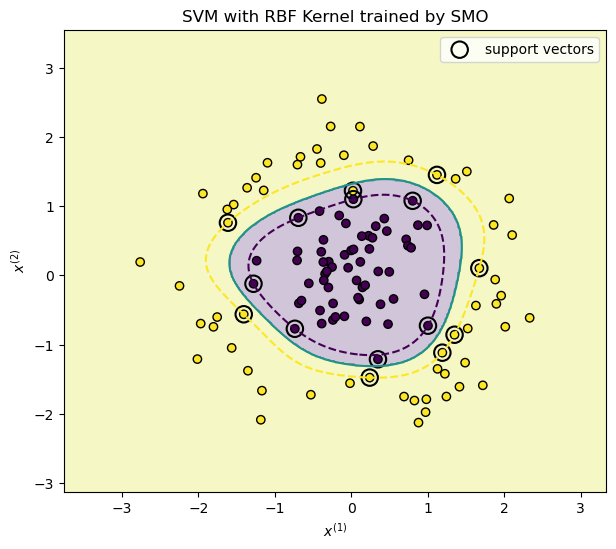

In [5]:
if __name__ == "__main__":
    rng = np.random.default_rng(0)

    # =====================================================
    # 1. 构造二维非线性数据：内圈 vs 外圈
    # =====================================================
    n_inner = 60
    n_outer = 60

    X_inner = 0.55 * rng.normal(size=(n_inner, 2))
    y_inner = -np.ones(n_inner)

    theta = rng.uniform(0, 2 * np.pi, size=n_outer)
    radius = 2.0 + 0.25 * rng.normal(size=n_outer)

    X_outer = np.c_[
        radius * np.cos(theta),
        radius * np.sin(theta)
    ]
    y_outer = np.ones(n_outer)

    X = np.vstack([X_inner, X_outer])
    y = np.hstack([y_inner, y_outer])

    # =====================================================
    # 2. 训练 SMO-RBF-SVM
    # =====================================================
    model = SMORBFClassifier(
        C=10.0,
        sigma=0.8,
        tol=1e-3,
        eps=1e-5,
        max_iter=10000,
        random_state=42,
        verbose=False
    )

    model.fit(X, y)

    print("模型信息:")
    print(model.summary())
    print("训练集准确率:", model.score(X, y))

    # =====================================================
    # 3. 类外可视化
    # =====================================================
    plot_svm_2d(model, X, y)

## sklearn.SVC

In [6]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


# 1. 构造非线性二分类数据
X, y = make_moons(
    n_samples=300,
    noise=0.25,
    random_state=42
)

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. 建立 SVC 模型
model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(
        C=1.0,
        kernel="rbf",
        gamma="scale"
    ))
])

# 4. 训练
model.fit(X_train, y_train)

# 5. 预测
y_pred = model.predict(X_test)

# 6. 评估
print("准确率:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

准确率: 0.85
              precision    recall  f1-score   support

           0       0.92      0.77      0.84        30
           1       0.80      0.93      0.86        30

    accuracy                           0.85        60
   macro avg       0.86      0.85      0.85        60
weighted avg       0.86      0.85      0.85        60

